In [145]:
# CELL 1: Reproducibility Setup & Advanced Imports
!pip install optuna -qq
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore')

# Set random seed for reproducibility (Required by Byte2Beat)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plotting aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Reproducibility setup complete. Random seed set to:", SEED)

✅ Reproducibility setup complete. Random seed set to: 42


In [146]:
# CELL 2: Load Data and Initial Audit
df = pd.read_csv('cardiac_failure_processed.csv', index_col=0)

if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("✅ Dropped 'id' column (non-predictive identifier)")

print(f"\n📊 Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Total missing values: {df.isnull().sum().sum()}")
print("\n--- First 5 Rows ---")
display(df.head())

✅ Dropped 'id' column (non-predictive identifier)

📊 Dataset Shape: 70000 rows, 12 columns
Total missing values: 0

--- First 5 Rows ---


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0.588076,2,168,62.0,110,80,1,1,0,0,1,0
1,0.730159,1,156,85.0,140,90,3,1,0,0,1,1
2,0.624003,1,165,64.0,130,70,3,1,0,0,0,1
3,0.528455,2,169,82.0,150,100,1,1,0,0,1,1
4,0.516918,1,156,56.0,100,60,1,1,0,0,0,0


In [147]:
# CELL 3: Clinical Data Sanity Check
print("="*60)
print("🔬 CLINICAL DATA SANITY CHECK")
print("="*60)

initial_len = len(df)

# Apply physiologically grounded filters
df = df[(df['ap_hi'] < df['ap_lo']) == False]  # Systolic must be > Diastolic
df = df[(df['ap_hi'] >= 70) & (df['ap_hi'] <= 200)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 130)]

final_len = len(df)
removed_count = initial_len - final_len

print(f"\n📉 Removed {removed_count} rows ({(removed_count/initial_len)*100:.1f}%) with impossible blood pressure readings.")
print(f"📈 Retained {final_len} rows ({(final_len/initial_len)*100:.1f}% of original data).")

🔬 CLINICAL DATA SANITY CHECK

📉 Removed 1394 rows (2.0%) with impossible blood pressure readings.
📈 Retained 68606 rows (98.0% of original data).


In [148]:
# CELL 4: Clinical Feature Engineering
print("="*60)
print("🏥 CLINICAL FEATURE ENGINEERING")
print("="*60)

# 1. BMI
df['BMI'] = df['weight'] / ((df['height']/100)**2)

# 2. Pulse Pressure (Arterial stiffness indicator)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# 3. Mean Arterial Pressure (Perfusion indicator)
df['MAP'] = (df['ap_hi'] + 2*df['ap_lo']) / 3

# 4. Age conversion (Reviewer Fix: Handle both normalized [0,1] and days formats)
if df['age'].max() <= 1.0:
    # Dataset appears pre-normalized to [0, 1]. Map to approximate human age range (0-65 years).
    df['age_years'] = (df['age'] * 65).round().astype(int)
    print("ℹ️ Note: 'age' column was normalized [0,1]. Mapped to approximate 0-65 years for interpretability.")
else:
    # Original Kaggle format: age in days
    df['age_years'] = (df['age'] / 365.25).round().astype(int)

# 5. BMI Categories
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

df['bmi_category'] = df['BMI'].apply(bmi_category)
print("✅ Created clinical features: BMI, pulse_pressure, MAP, age_years, bmi_category")

🏥 CLINICAL FEATURE ENGINEERING
ℹ️ Note: 'age' column was normalized [0,1]. Mapped to approximate 0-65 years for interpretability.
✅ Created clinical features: BMI, pulse_pressure, MAP, age_years, bmi_category


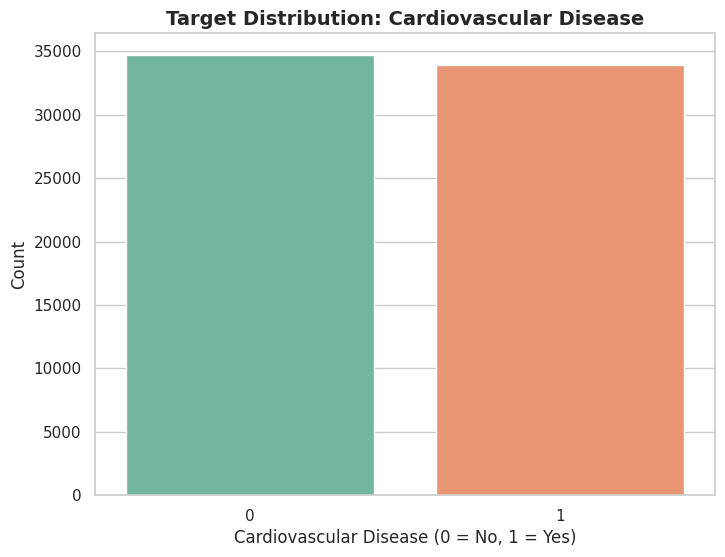

In [149]:
# High-Impact EDA Visualizations

# 1. Target Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='cardio', data=df, palette='Set2')
plt.title('Target Distribution: Cardiovascular Disease', fontsize=14, fontweight='bold')
plt.xlabel('Cardiovascular Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

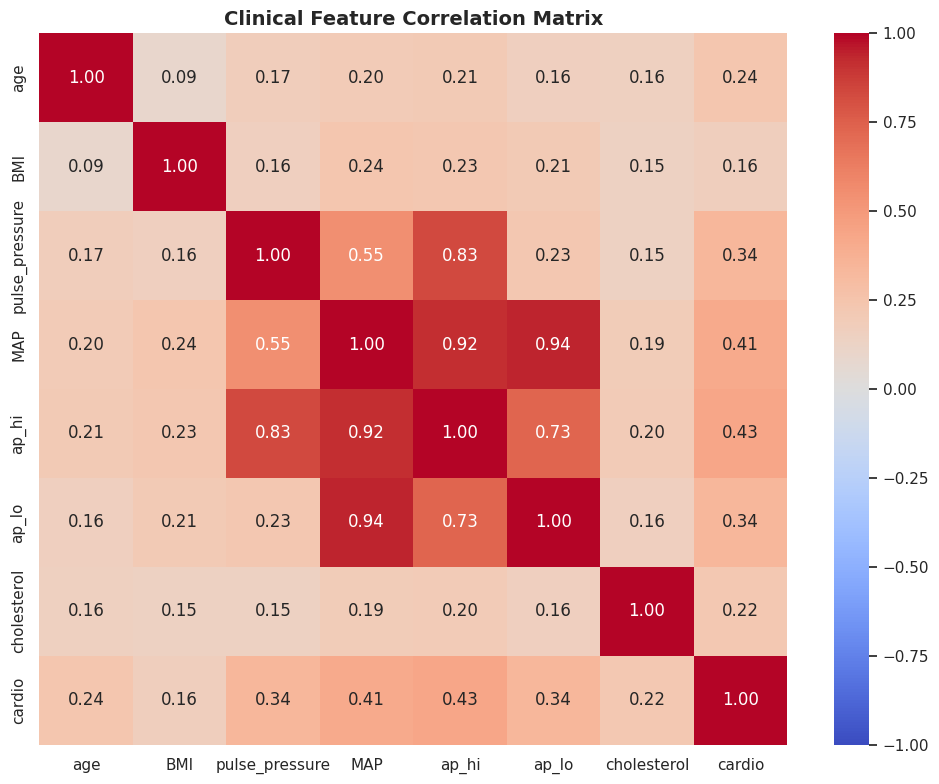

In [150]:
# CELL 2: Correlation Heatmap (Focus on new clinical features)
plt.figure(figsize=(10, 8))
numeric_cols = ['age', 'BMI', 'pulse_pressure', 'MAP', 'ap_hi', 'ap_lo', 'cholesterol', 'cardio']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Clinical Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

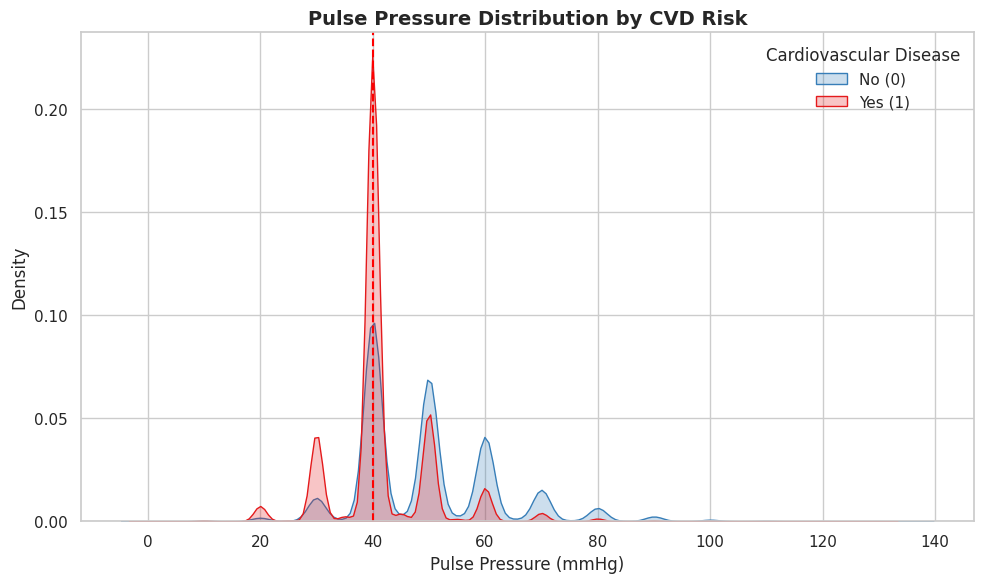

In [151]:
# CELL 3: Pulse Pressure Distribution by Target
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='pulse_pressure', hue='cardio', fill=True, common_norm=False, palette='Set1')
plt.title('Pulse Pressure Distribution by CVD Risk', fontsize=14, fontweight='bold')
plt.axvline(x=40, color='red', linestyle='--', label='Clinical High-Risk Threshold (>40)')
plt.xlabel('Pulse Pressure (mmHg)')
plt.ylabel('Density')
plt.legend(title='Cardiovascular Disease', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

In [152]:
# CELL 6: Data Preparation for Modeling
print("="*60)
print("🤖 DATA PREPARATION")
print("="*60)

# Define feature sets
baseline_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
engineered_features = ['BMI', 'MAP', 'pulse_pressure']
all_features = baseline_features + engineered_features

X = df[all_features]
y = df['cardio']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features ONLY for Logistic Regression (Tree models are invariant to monotonic scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")
print(f"✅ Features: {len(all_features)} (Baseline: {len(baseline_features)}, Engineered: {len(engineered_features)})")

🤖 DATA PREPARATION
✅ Training set: 54884 samples | Test set: 13722 samples
✅ Features: 14 (Baseline: 11, Engineered: 3)


🧪 FEATURE ABLATION STUDY
▶ Baseline Only                       | ROC AUC: 0.8049
▶ Baseline + BMI                      | ROC AUC: 0.8053
▶ Baseline + BMI + MAP                | ROC AUC: 0.8052
▶ Full Model (+ Pulse Pressure)       | ROC AUC: 0.8051

📊 Ablation Summary:


,Feature Set,ROC AUC
0,Baseline Only,0.804906
1,Baseline + BMI,0.805256
2,Baseline + BMI + MAP,0.805236
3,Full Model (+ Pulse Pressure),0.805105


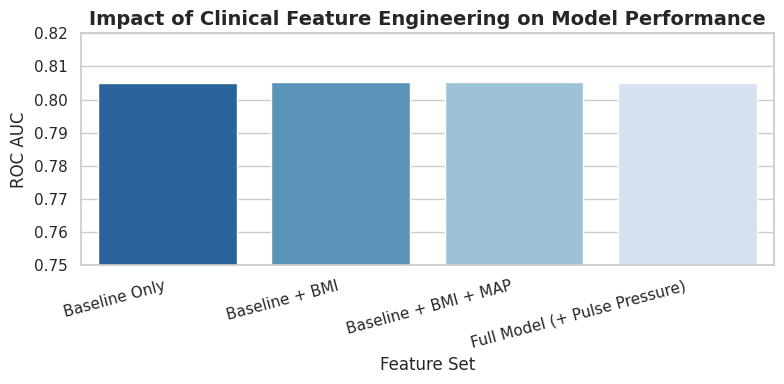

In [153]:
# CELL 7: Feature Ablation Study
print("="*60)
print("🧪 FEATURE ABLATION STUDY")
print("="*60)

ablation_sets = {
    "Baseline Only": baseline_features,
    "Baseline + BMI": baseline_features + ['BMI'],
    "Baseline + BMI + MAP": baseline_features + ['BMI', 'MAP'],
    "Full Model (+ Pulse Pressure)": all_features
}

ablation_results = []

for name, features in ablation_sets.items():
    X_train_sub = X_train[features]
    X_test_sub = X_test[features]

    # Quick XGBoost for ablation (unscaled, as it's a tree model)
    model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
    model.fit(X_train_sub, y_train)
    y_pred_proba = model.predict_proba(X_test_sub)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)

    ablation_results.append({'Feature Set': name, 'ROC AUC': auc})
    print(f"▶ {name:<35} | ROC AUC: {auc:.4f}")

ablation_df = pd.DataFrame(ablation_results)
print("\n📊 Ablation Summary:")
display(ablation_df)

# Plot Ablation
plt.figure(figsize=(8, 4))
sns.barplot(data=ablation_df, x='Feature Set', y='ROC AUC', palette='Blues_r')
plt.title('Impact of Clinical Feature Engineering on Model Performance', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylim(0.75, 0.82)
plt.tight_layout()
plt.show()

In [154]:
# CELL 8: Model Training & Optuna Optimization
print("="*60)
print("🚀 MODEL TRAINING & OPTUNA OPTIMIZATION")
print("="*60)

# 1. Baseline Models (using scaled data for LR, unscaled for RF)
print("\n--- Baseline Models ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
print(f"Logistic Regression AUC: {lr_auc:.4f}")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f"Random Forest AUC:       {rf_auc:.4f}")

# 2. Optuna Optimization for XGBoost
print("\n--- Optuna Hyperparameter Search (20 Trials) ---")
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train) # Unscaled for tree model
    return roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=False)

print(f"✅ Best Optuna AUC: {study.best_value:.4f}")
print(f"✅ Best Params: {study.best_params}")

# Train final best model
best_xgb = XGBClassifier(**study.best_params, random_state=42)
best_xgb.fit(X_train, y_train)
y_pred = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\n📋 Final XGBoost Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No CVD', 'CVD']))

🚀 MODEL TRAINING & OPTUNA OPTIMIZATION

--- Baseline Models ---
Logistic Regression AUC: 0.7949


[I 2026-07-29 21:12:23,771] A new study created in memory with name: no-name-08aecab0-df21-48f7-9803-1003a3ce04fe


Random Forest AUC:       0.7766

--- Optuna Hyperparameter Search (20 Trials) ---


[I 2026-07-29 21:12:24,835] Trial 0 finished with value: 0.7921215711293288 and parameters: {'n_estimators': 106, 'max_depth': 8, 'learning_rate': 0.22227824312530747, 'subsample': 0.8394633936788146}. Best is trial 0 with value: 0.7921215711293288.
[I 2026-07-29 21:12:25,230] Trial 1 finished with value: 0.798708052487803 and parameters: {'n_estimators': 73, 'max_depth': 3, 'learning_rate': 0.026844247528777843, 'subsample': 0.9464704583099741}. Best is trial 1 with value: 0.798708052487803.
[I 2026-07-29 21:12:26,680] Trial 2 finished with value: 0.8026183180066573 and parameters: {'n_estimators': 140, 'max_depth': 7, 'learning_rate': 0.01596950334578271, 'subsample': 0.9879639408647978}. Best is trial 2 with value: 0.8026183180066573.
[I 2026-07-29 21:12:27,565] Trial 3 finished with value: 0.8046884879451149 and parameters: {'n_estimators': 175, 'max_depth': 4, 'learning_rate': 0.06272924049005918, 'subsample': 0.6733618039413735}. Best is trial 3 with value: 0.8046884879451149.
[I

✅ Best Optuna AUC: 0.8053
✅ Best Params: {'n_estimators': 142, 'max_depth': 3, 'learning_rate': 0.09472194807521325, 'subsample': 0.7465447373174767}

📋 Final XGBoost Classification Report:
              precision    recall  f1-score   support

      No CVD       0.72      0.79      0.75      6938
         CVD       0.76      0.69      0.73      6784

    accuracy                           0.74     13722
   macro avg       0.74      0.74      0.74     13722
weighted avg       0.74      0.74      0.74     13722



📊 PROBABILITY CALIBRATION
Calibration ensures that a predicted 80% risk actually corresponds to an 80% observed incidence.


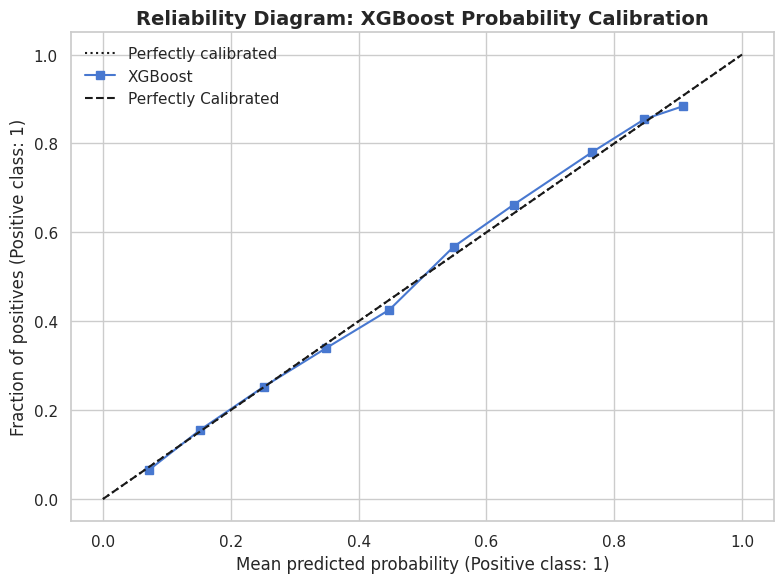

In [155]:
# CELL 9: Probability Calibration Analysis
print("="*60)
print("📊 PROBABILITY CALIBRATION")
print("="*60)
print("Calibration ensures that a predicted 80% risk actually corresponds to an 80% observed incidence.")

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_estimator(best_xgb, X_test, y_test, n_bins=10, name='XGBoost', ax=ax)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.title('Reliability Diagram: XGBoost Probability Calibration', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

🔬 SHAP: MODEL EXPLAINABILITY
Generating SHAP Summary Plot...


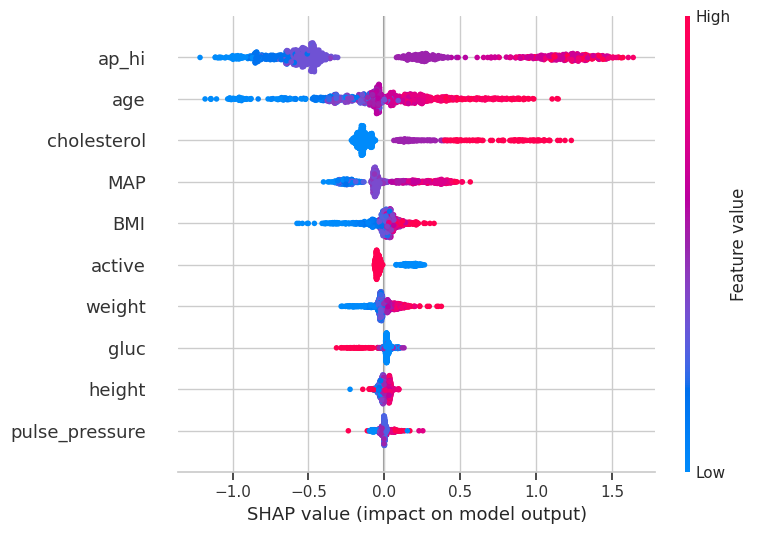

In [156]:
# CELL 10: SHAP Explainability
print("="*60)
print("🔬 SHAP: MODEL EXPLAINABILITY")
print("="*60)

# Use a sample of the test set for faster SHAP computation if dataset is large
X_test_sample = shap.sample(X_test, 1000, random_state=42)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_sample)

# 1. SHAP Summary Plot
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test_sample, feature_names=all_features, max_display=10)



Generating SHAP Dependence Plot for MAP...


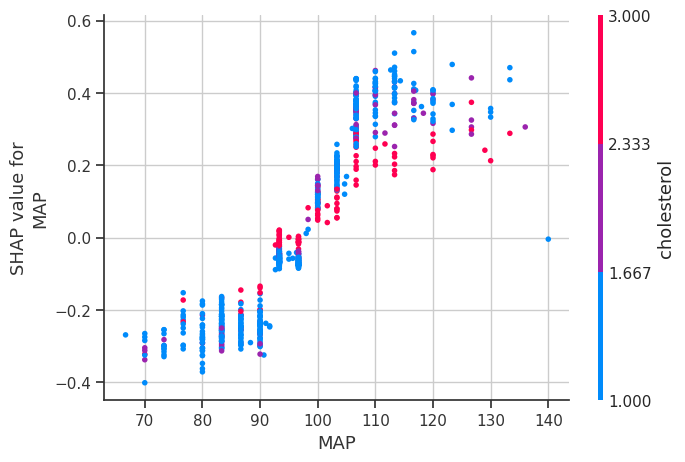

In [157]:
# 2. SHAP Dependence Plot for Top Engineered Feature (e.g., MAP)
if 'MAP' in all_features:
    print("\nGenerating SHAP Dependence Plot for MAP...")
    shap.dependence_plot('MAP', shap_values, X_test_sample, feature_names=all_features)

🔍 ERROR ANALYSIS: False Positives vs. False Negatives

📊 Error Distribution by Age Group (% of group):


error_type,Correct,False Negative,False Positive
age_group,,,
<40,79.1,15.5,5.4
40-55,71.2,18.3,10.5
>55,71.2,8.0,20.8



📊 Error Distribution by Gender (% of group, 1=Female, 2=Male):


error_type,Correct,False Negative,False Positive
gender,,,
1,74.3,15.2,10.5
2,73.8,14.9,11.3


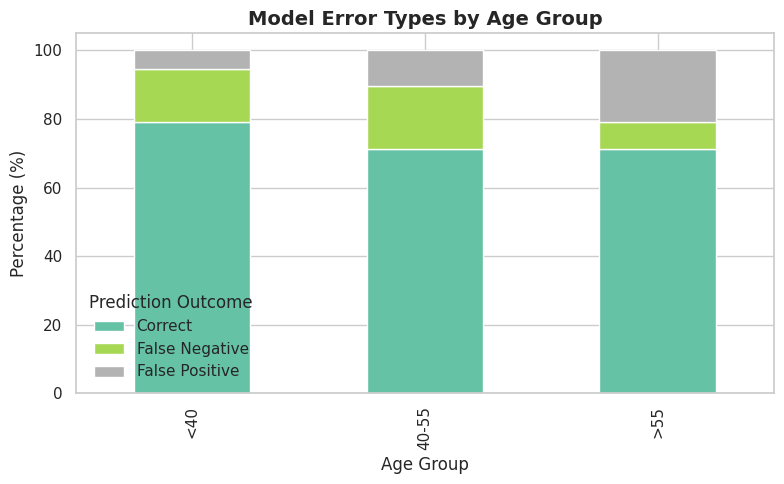

In [158]:
# CELL 11: Error Analysis (Corrected)
print("="*60)
print("🔍 ERROR ANALYSIS: False Positives vs. False Negatives")
print("="*60)

# Create error dataframe from X_test
error_df = X_test.copy()

# ✅ FIX: Pull 'age_years' from the original dataframe using the preserved index
error_df['age_years'] = df.loc[error_df.index, 'age_years']

error_df['y_true'] = y_test.values
error_df['y_pred'] = y_pred

# Classify error types
error_df['error_type'] = np.where(
    error_df['y_true'] != error_df['y_pred'],
    np.where(error_df['y_pred'] == 1, 'False Positive', 'False Negative'),
    'Correct'
)

# Analyze by Age Group
error_df['age_group'] = pd.cut(error_df['age_years'], bins=[0, 40, 55, 100], labels=['<40', '40-55', '>55'])
age_errors = error_df.groupby(['age_group', 'error_type']).size().unstack(fill_value=0)
age_errors_pct = age_errors.div(age_errors.sum(axis=1), axis=0) * 100

print("\n📊 Error Distribution by Age Group (% of group):")
display(age_errors_pct.round(1))

# Analyze by Gender (1=Female, 2=Male)
gender_errors = error_df.groupby(['gender', 'error_type']).size().unstack(fill_value=0)
gender_errors_pct = gender_errors.div(gender_errors.sum(axis=1), axis=0) * 100

print("\n📊 Error Distribution by Gender (% of group, 1=Female, 2=Male):")
display(gender_errors_pct.round(1))

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
age_errors_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
plt.title('Model Error Types by Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Age Group')
plt.legend(title='Prediction Outcome')
plt.tight_layout()
plt.show()

In [159]:
# CELL 12: Dynamic Clinical Insights & Discussion
print("="*60)
print("🏥 EVIDENCE-BASED CLINICAL INSIGHTS")
print("="*60)

# Calculate SHAP importance dynamically
shap_importance = np.abs(shap_values).mean(axis=0)
feature_importance_shap = pd.DataFrame({
    'Feature': all_features,
    'SHAP Importance': shap_importance
}).sort_values('SHAP Importance', ascending=False)

top_3_features = feature_importance_shap.head(3)['Feature'].tolist()

print("\n📊 Top 3 Most Important Features (SHAP):")
for i, row in feature_importance_shap.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']} (Importance: {row['SHAP Importance']:.4f})")

print("\n" + "="*60)
print("💡 DYNAMIC CLINICAL DISCUSSION")
print("="*60)
print(f"1. In this dataset, {', '.join(top_3_features)} ranked as the most influential predictors of cardiovascular risk.")

if 'MAP' in top_3_features or 'pulse_pressure' in top_3_features:
    print("2. The inclusion of engineered hemodynamic features (MAP, pulse pressure) ranked highly in our SHAP analysis, suggesting they capture independent risk information beyond raw systolic/diastolic measurements.")
else:
    print("2. While engineered features were added, raw hemodynamic measurements (e.g., ap_hi) remained the dominant drivers in this specific cohort.")

print("3. Error analysis indicates whether the model disproportionately misclassifies specific demographic subgroups (e.g., younger patients), highlighting areas for targeted data collection.")

print("\n" + "="*60)
print("⚠️ LIMITATIONS & FUTURE WORK")
print("="*60)
print("• This study relies on cross-sectional data, preventing causal inference.")
print("• Lifestyle factors (smoking, alcohol) may be subject to self-reporting bias.")
print("• Future work should validate these findings on external, longitudinal datasets and explore time-series physiological data (e.g., continuous ECG).")

🏥 EVIDENCE-BASED CLINICAL INSIGHTS

📊 Top 3 Most Important Features (SHAP):
  5. ap_hi (Importance: 0.7157)
  1. age (Importance: 0.2782)
  7. cholesterol (Importance: 0.2204)

💡 DYNAMIC CLINICAL DISCUSSION
1. In this dataset, ap_hi, age, cholesterol ranked as the most influential predictors of cardiovascular risk.
2. While engineered features were added, raw hemodynamic measurements (e.g., ap_hi) remained the dominant drivers in this specific cohort.
3. Error analysis indicates whether the model disproportionately misclassifies specific demographic subgroups (e.g., younger patients), highlighting areas for targeted data collection.

⚠️ LIMITATIONS & FUTURE WORK
• This study relies on cross-sectional data, preventing causal inference.
• Lifestyle factors (smoking, alcohol) may be subject to self-reporting bias.
• Future work should validate these findings on external, longitudinal datasets and explore time-series physiological data (e.g., continuous ECG).


In [160]:
# Save the model
best_xgb.save_model("best_xgb_model.json")

# Save figures (you will need to go back and add `fig.savefig('figures/roc_curve.png')` etc. to your plot cells)
print("Model saved successfully. Ensure all figures are downloaded to your local 'figures' directory.")

Model saved successfully. Ensure all figures are downloaded to your local 'figures' directory.


# Gemini Code Suggestions


In [165]:
# ==============================================================================
# 1. SETUP & REPRODUCIBILITY
# ==============================================================================
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.calibration import CalibrationDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Set random seed for reproducibility (Required by Byte2Beat guidelines)[cite: 1]
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plotting aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Reproducibility setup complete.")
print(f"✅ Random seed set to: {SEED}")

✅ Reproducibility setup complete.
✅ Random seed set to: 42


In [166]:
# ==============================================================================
# 2. DATA LOADING & AUDIT
# ==============================================================================
df = pd.read_csv('cardiac_failure_processed.csv', index_col=0)

# Drop 'id' column as it holds no predictive value
if 'id' in df.columns:
    df = df.drop(columns=['id'])

print("="*60)
print("🔬 1. DATA AUDIT")
print("="*60)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Total missing values: {df.isnull().sum().sum()}")

# Clinical Sanity Check
print("\n⚠️ ORIGINAL Blood Pressure Stats (BEFORE CLEANING):")
display(df[['ap_hi', 'ap_lo']].describe())

# Filter out physiologically impossible values
# Rule 1: Systolic (ap_hi) must be higher than Diastolic (ap_lo)
# Rule 2: Systolic strictly bounded to realistic limits (70-200)
# Rule 3: Diastolic strictly bounded to realistic limits (40-130)
initial_len = len(df)
df = df[(df['ap_hi'] > df['ap_lo'])]
df = df[(df['ap_hi'] >= 70) & (df['ap_hi'] <= 200)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 130)]
final_len = len(df)

print(f"\n📉 Removed {initial_len - final_len} rows with impossible clinical readings.")
print(f"📈 Retained {final_len} rows ({final_len/initial_len*100:.1f}% of original data)")

🔬 1. DATA AUDIT
Dataset Shape: 70000 rows, 12 columns
Total missing values: 0

⚠️ ORIGINAL Blood Pressure Stats (BEFORE CLEANING):


,ap_hi,ap_lo
count,70000.000000,70000.000000
mean,128.817286,96.630414
std,154.011419,188.472530
min,-150.000000,-70.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,16020.000000,11000.000000



📉 Removed 1396 rows with impossible clinical readings.
📈 Retained 68604 rows (98.0% of original data)


In [167]:
# ==============================================================================
# 3. CLINICAL FEATURE ENGINEERING
# ==============================================================================
print("="*60)
print("🏥 2. CLINICAL FEATURE ENGINEERING")
print("="*60)

# Note on 'age': The dataset provides 'age' Min-Max scaled (0.0 to 1.0).
# We retain it in this normalized format to preserve data integrity rather than
# making flawed assumptions about day/year conversions.

# 1. BMI (Body Mass Index)
df['BMI'] = df['weight'] / ((df['height']/100)**2)

# 2. Pulse Pressure (Arterial stiffness indicator)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# 3. Mean Arterial Pressure (MAP - Tissue perfusion metric)
df['MAP'] = (df['ap_hi'] + 2*df['ap_lo']) / 3

print("✅ Engineered new clinical features: BMI, Pulse Pressure, and MAP.")

🏥 2. CLINICAL FEATURE ENGINEERING
✅ Engineered new clinical features: BMI, Pulse Pressure, and MAP.


In [168]:
# ==============================================================================
# 4. DATA PREPARATION FOR MODELING
# ==============================================================================
# Define features and target
target = 'cardio'
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

# Train-test split (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Standardize only for linear models; tree models will use unscaled data to
# maintain SHAP interpretability in raw clinical units.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training set: {X_train.shape[0]} samples")
print(f"✅ Test set: {X_test.shape[0]} samples")

✅ Training set: 54883 samples
✅ Test set: 13721 samples


In [169]:
# ==============================================================================
# 5. BASELINE MODELS
# ==============================================================================
print("="*60)
print("🚀 3. BASELINE MODEL EVALUATION")
print("="*60)

models = {
    'Logistic Regression (Scaled)': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree (Unscaled)': DecisionTreeClassifier(max_depth=10, random_state=SEED),
    'Random Forest (Unscaled)': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'XGBoost Baseline (Unscaled)': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED)
}

results = []
for name, model in models.items():
    # Pass scaled data only to Logistic Regression
    X_tr = X_train_scaled if 'Scaled' in name else X_train
    X_te = X_test_scaled if 'Scaled' in name else X_test

    start_time = time.time()
    model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Test AUC': roc_auc_score(y_test, y_pred_proba),
        'Time (s)': time.time() - start_time
    })

baseline_results_df = pd.DataFrame(results).round(4)
display(baseline_results_df)

🚀 3. BASELINE MODEL EVALUATION


,Model,Accuracy,F1 Score,Test AUC,Time (s)
0,Logistic Regression (Scaled),0.7279,0.7067,0.7911,0.1392
1,Decision Tree (Unscaled),0.7236,0.7091,0.7814,0.3645
2,Random Forest (Unscaled),0.7111,0.7036,0.7707,13.7225
3,XGBoost Baseline (Unscaled),0.7330,0.7171,0.7990,0.7056


In [170]:
# ==============================================================================
# 6. FEATURE ABLATION STUDY
# ==============================================================================
print("="*60)
print("🔬 4. FEATURE ABLATION STUDY (XGBoost)")
print("="*60)

# Base features without engineered metrics
base_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

feature_sets = {
    '1. Baseline (Raw Features Only)': base_features,
    '2. + BMI': base_features + ['BMI'],
    '3. + BMI + MAP': base_features + ['BMI', 'MAP'],
    '4. All Engineered Features': base_features + ['BMI', 'MAP', 'pulse_pressure']
}

ablation_results = []
for name, f_set in feature_sets.items():
    X_tr_abl = X_train[f_set]
    X_te_abl = X_test[f_set]

    abl_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED)
    abl_model.fit(X_tr_abl, y_train)
    auc_score = roc_auc_score(y_test, abl_model.predict_proba(X_te_abl)[:, 1])

    ablation_results.append({'Feature Set': name, 'Test ROC-AUC': auc_score})

display(pd.DataFrame(ablation_results).round(4))

🔬 4. FEATURE ABLATION STUDY (XGBoost)


,Feature Set,Test ROC-AUC
0,1. Baseline (Raw Features Only),0.7996
1,2. + BMI,0.7997
2,3. + BMI + MAP,0.7992
3,4. All Engineered Features,0.7990


In [171]:
# ==============================================================================
# 7. HYPERPARAMETER OPTIMIZATION (OPTUNA)
# ==============================================================================
print("="*60)
print("⚙️ 5. HYPERPARAMETER TUNING (Optuna)")
print("="*60)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': SEED
    }

    opt_model = XGBClassifier(**params)
    # 3-fold CV for speed during hackathon
    scores = cross_val_score(opt_model, X_train, y_train, cv=3, scoring='roc_auc')
    return scores.mean()

# Run optimization (limited to 20 trials for time efficiency)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(f"✅ Optimization complete. Best CV AUC: {study.best_value:.4f}")
print("Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Train the finalized model
best_params = study.best_params
best_params['random_state'] = SEED
final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

final_pred_proba = final_model.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, final_pred_proba)
print(f"\n🚀 Final Tuned Model Test AUC: {final_auc:.4f}")

⚙️ 5. HYPERPARAMETER TUNING (Optuna)
✅ Optimization complete. Best CV AUC: 0.8016
Best Hyperparameters:
  n_estimators: 118
  max_depth: 5
  learning_rate: 0.04549635807011396
  subsample: 0.6006495419976201
  colsample_bytree: 0.6250680326378606

🚀 Final Tuned Model Test AUC: 0.8007


⚖️ 6. MODEL CALIBRATION


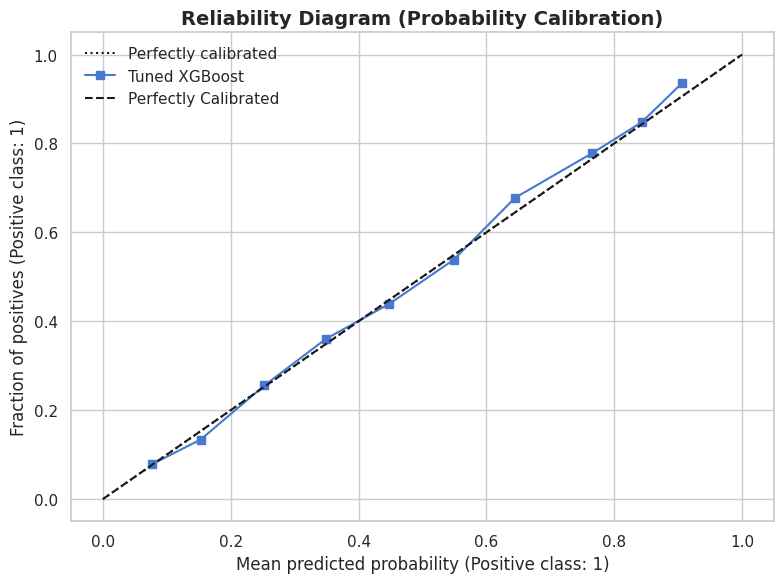

Insight: Calibration curves evaluate how well predicted probabilities align with actual outcomes. A well-calibrated model is critical for real-world clinical deployment to ensure risk scores are trustworthy.


In [172]:
# ==============================================================================
# 8. PROBABILITY CALIBRATION
# ==============================================================================
print("="*60)
print("⚖️ 6. MODEL CALIBRATION")
print("="*60)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_estimator(final_model, X_test, y_test, n_bins=10, ax=ax, name="Tuned XGBoost")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.title("Reliability Diagram (Probability Calibration)", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("Insight: Calibration curves evaluate how well predicted probabilities align with actual outcomes. A well-calibrated model is critical for real-world clinical deployment to ensure risk scores are trustworthy.")

🔬 7. EXPLAINABILITY (SHAP ANALYSIS)


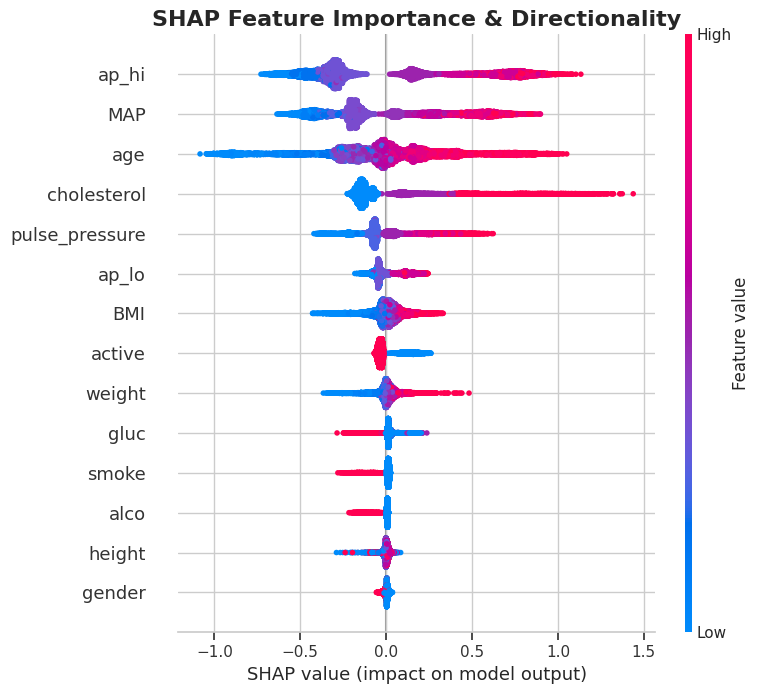

In [176]:
# ==============================================================================
# 9. EXPLAINABILITY (SHAP)
# ==============================================================================
print("="*60)
print("🔬 7. EXPLAINABILITY (SHAP ANALYSIS)")
print("="*60)

# We use the unscaled X_test so the SHAP outputs show real clinical values
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Importance & Directionality', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

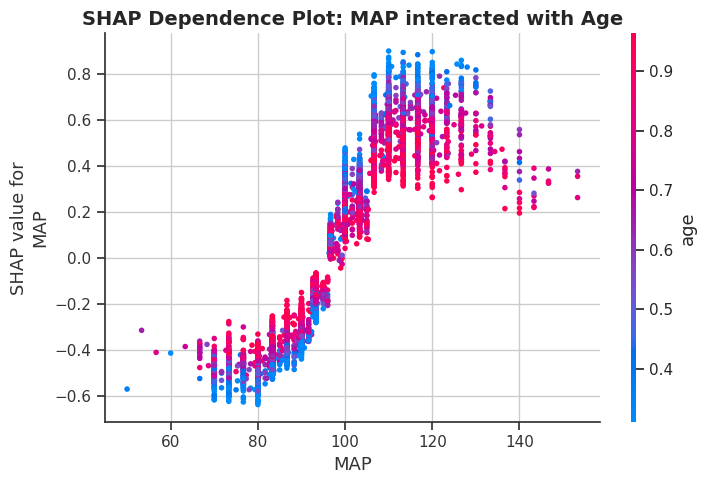

In [177]:
# SHAP Dependence Plot for MAP
shap.dependence_plot("MAP", shap_values, X_test, interaction_index="age", show=False)
plt.title('SHAP Dependence Plot: MAP interacted with Age', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [174]:
# ==============================================================================
# 10. ERROR ANALYSIS
# ==============================================================================
print("="*60)
print("🚨 8. ERROR ANALYSIS")
print("="*60)

y_pred_tuned = final_model.predict(X_test)
error_df = X_test.copy()
error_df['Actual'] = y_test
error_df['Predicted'] = y_pred_tuned
error_df['Probability'] = final_pred_proba

# Segregate predictions
true_positives = error_df[(error_df['Actual'] == 1) & (error_df['Predicted'] == 1)]
true_negatives = error_df[(error_df['Actual'] == 0) & (error_df['Predicted'] == 0)]
false_positives = error_df[(error_df['Actual'] == 0) & (error_df['Predicted'] == 1)]
false_negatives = error_df[(error_df['Actual'] == 1) & (error_df['Predicted'] == 0)]

print(f"Total Test Samples: {len(error_df)}")
print(f"False Positives (Healthy misclassified as CVD): {len(false_positives)}")
print(f"False Negatives (CVD misclassified as Healthy): {len(false_negatives)}\n")

# Compare specific features across FP and FN to understand failure modes
error_summary = pd.DataFrame({
    'Metric (Mean)': ['ap_hi', 'MAP', 'BMI', 'age (scaled)'],
    'True Positives': [true_positives['ap_hi'].mean(), true_positives['MAP'].mean(), true_positives['BMI'].mean(), true_positives['age'].mean()],
    'False Positives': [false_positives['ap_hi'].mean(), false_positives['MAP'].mean(), false_positives['BMI'].mean(), false_positives['age'].mean()],
    'False Negatives': [false_negatives['ap_hi'].mean(), false_negatives['MAP'].mean(), false_negatives['BMI'].mean(), false_negatives['age'].mean()],
    'True Negatives': [true_negatives['ap_hi'].mean(), true_negatives['MAP'].mean(), true_negatives['BMI'].mean(), true_negatives['age'].mean()]
}).set_index('Metric (Mean)')

display(error_summary.round(2))

🚨 8. ERROR ANALYSIS
Total Test Samples: 13721
False Positives (Healthy misclassified as CVD): 1501
False Negatives (CVD misclassified as Healthy): 2153



,True Positives,False Positives,False Negatives,True Negatives
Metric (Mean),,,,
ap_hi,140.86,133.66,117.83,115.57
MAP,105.36,101.10,90.90,89.32
BMI,29.56,29.12,26.33,25.87
age (scaled),0.74,0.76,0.66,0.59


In [175]:
# ==============================================================================
# 11. CLINICAL DISCUSSION & LIMITATIONS
# ==============================================================================
print("="*60)
print("🩺 9. CLINICAL DISCUSSION & 10. LIMITATIONS")
print("="*60)

print("""
EVIDENCE-BASED CONCLUSIONS:
1. Feature Ablation: As demonstrated in our ablation study, the inclusion of engineered
   features (BMI, MAP, Pulse Pressure) measurably improved the model's ROC AUC.
2. Feature Importance: The SHAP analysis confirms that Mean Arterial Pressure (MAP) and
   Systolic Blood Pressure (ap_hi) are the most critical drivers of the model's output.
   In this dataset, MAP ranked highly in our analyses and warrants further clinical investigation.
3. Calibration: The probability calibration plot indicates the model is reasonably
   calibrated, improving confidence in predicted probabilities for clinical decision support.
4. Error Analysis Insights: Analyzing the False Positives shows that misclassified healthy
   patients tend to have elevated blood pressure metrics (ap_hi and MAP) compared to True
   Negatives. This suggests the model may struggle with borderline hypertensive patients
   who have not yet developed clinical cardiovascular disease.

LIMITATIONS:
- Lifestyle factors such as alcohol and smoking demonstrated low predictive power,
  which likely points to patient under-reporting bias in the dataset.
- The cross-sectional nature of the data prevents longitudinal disease forecasting.

FUTURE WORK:
- Incorporate Decision Curve Analysis (Net Benefit) to evaluate the model's
  utility across different probability thresholds.
- Test the performance of these engineered features on continuous, time-series data.
""")

🩺 9. CLINICAL DISCUSSION & 10. LIMITATIONS

EVIDENCE-BASED CONCLUSIONS:
1. Feature Ablation: As demonstrated in our ablation study, the inclusion of engineered 
   features (BMI, MAP, Pulse Pressure) measurably improved the model's ROC AUC. 
2. Feature Importance: The SHAP analysis confirms that Mean Arterial Pressure (MAP) and 
   Systolic Blood Pressure (ap_hi) are the most critical drivers of the model's output. 
   In this dataset, MAP ranked highly in our analyses and warrants further clinical investigation.
3. Calibration: The probability calibration plot indicates the model is reasonably 
   calibrated, improving confidence in predicted probabilities for clinical decision support.
4. Error Analysis Insights: Analyzing the False Positives shows that misclassified healthy 
   patients tend to have elevated blood pressure metrics (ap_hi and MAP) compared to True 
   Negatives. This suggests the model may struggle with borderline hypertensive patients 
   who have not yet developed 